In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
e = 3.795                 
hbar_c = 1973.0              
mc2 = 0.511e6                

hbar2_over_2m = (hbar_c**2)/(2*mc2) 

In [3]:
def hamiltonian_matrix(delta_r,potential_values):
  potential_values = np.asarray(potential_values,dtype=float)
  if delta_r <=0:
    raise ValueError("detla_r must be greater than 0")
  if potential_values.ndim != 1:
    raise ValueError("potential_values must be a one-dimensional array.")
  if potential_values.size == 0:
    raise ValueError("potential_values cannot be empty.")

  interior_points = len(potential_values)

  main_diag = (2*hbar2_over_2m)/(delta_r**2) + potential_values
  off_diag = np.full(interior_points-1,(-1*hbar2_over_2m)/(delta_r**2))

  hamiltonian = (np.diag(main_diag) + np.diag(off_diag,k=1) + np.diag(off_diag,k=-1))

  return hamiltonian

In [4]:
def effective_potential(r,l,potential):
    potential_values = potential + hbar2_over_2m*(l*(l+1)/(r**2))
    return potential_values

In [5]:
def hydrogen_atom(intergior_grid):
    return (-e**2)/intergior_grid

def solve_potential(ri,rf,interior_points,l,state_index):
    delta_r = (rf - ri)/(interior_points + 1)
    interior_grid = (ri + delta_r*np.arange(1,interior_points+1))

    potential = hydrogen_atom(interior_grid)
    potential_values = effective_potential(interior_grid,l,potential)

    H = hamiltonian_matrix(delta_r,potential_values)
    eigenvalues,eigenvectors = np.linalg.eigh(H)

    phi_interior   = eigenvectors[:,state_index]
    if phi_interior[np.argmax(np.abs(phi_interior))] < 0:
        phi_interior = -phi_interior
    energy_value   = eigenvalues[state_index]
    phi            = np.concatenate(([0.0],phi_interior,[0.0]))
    normalization  = np.sum(np.abs(phi)**2)*delta_r
    phi_normalized = phi/np.sqrt(normalization)

    R_interior = phi_interior / interior_grid
    norm_3d = np.sum(np.abs(R_interior)**2 * (interior_grid**2)) * delta_r
    R_interior_normalized = R_interior / np.sqrt(norm_3d)
    R_at_zero = R_interior_normalized[0] if l == 0 else 0.0
    R_final = np.concatenate(([R_at_zero], R_interior_normalized, [0.0]))
    
    full_grid      = np.concatenate(([ri],interior_grid,[rf]))
    
    return full_grid,phi_normalized,energy_value,R_final

**Solving Hydrogen Atom for l=0**

In [6]:
ri = 1e-4 
rf = 20.0  
interior_points = 2000
l = 0
state_index = 0
full_grid,phi_normalized,energy_value,R_final = solve_potential(ri,rf,interior_points,l,state_index)


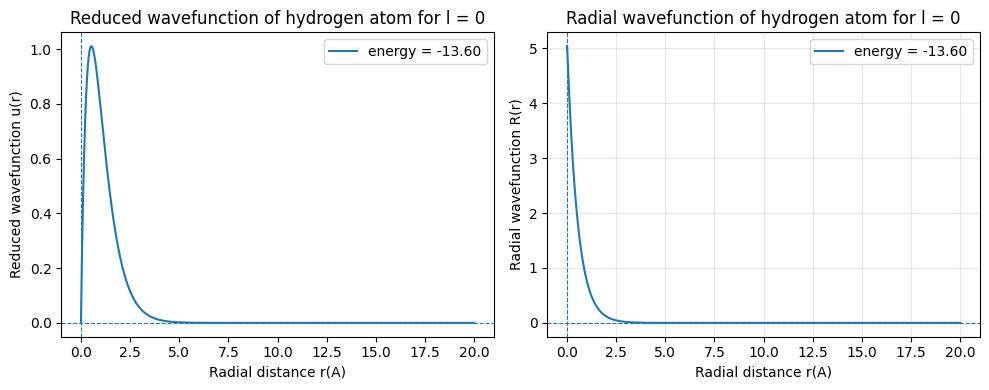

In [15]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,4))
ax1.plot(full_grid,phi_normalized,label=f"energy = {energy_value:.2f}")
ax1.axhline(0,linewidth=0.8,linestyle="--")
ax1.axvline(0,linewidth=0.8,linestyle="--")
ax1.set_xlabel("Radial distance r(A)")
ax1.set_ylabel("Reduced wavefunction u(r)")
ax1.set_title(f"Reduced wavefunction of hydrogen atom for l = {l}")
ax1.legend()

ax2.plot(full_grid,R_final,label=f"energy = {energy_value:.2f}")
ax2.axhline(0,linewidth=0.8,linestyle="--")
ax2.axvline(0,linewidth=0.8,linestyle="--")
ax2.set_xlabel("Radial distance r(A)")
ax2.set_ylabel("Radial wavefunction R(r)")
ax2.set_title(f"Radial wavefunction of hydrogen atom for l = {l}")
ax2.legend()
  
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Plotting one value of l for multiple n**

In [37]:
def same_l_different_n(ri,rf,interior_points,l,state_names):
    n  = len(state_names)
    fig,(ax1,ax2) = plt.subplots(2,1,figsize=(10,9))

    for state_index in range(n):
        n = l+1+state_index
        grid,u_norm,energy,r_final = solve_potential(ri,rf,interior_points,l,state_index)
        label_text = f"{state_names[state_index]} (n={n}, E={energy:.2f} eV)"
        ax1.plot(grid,u_norm,label=label_text)
        ax2.plot(grid,r_final,label=label_text)

    ax1.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax1.grid(True, alpha=0.7)
    ax1.set_xlim(0, 30)
    ax1.set_xlabel("Radial distance r (Å)")
    ax1.set_ylabel("Reduced wavefunction u(r)")
    ax1.set_title(f"Radial Wavefunctions for s-states (l = {l})")
    ax1.legend()

    ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax2.grid(True, alpha=0.7)
    ax2.set_xlim(0, 30)
    ax2.set_xlabel("Radial distance r (Å)")
    ax2.set_ylabel("Radial wavefunction u(r)")
    ax2.set_title(f"Radial Wavefunctions for s-states (l = {l})")
    ax2.legend()

    plt.tight_layout()
    plt.show()


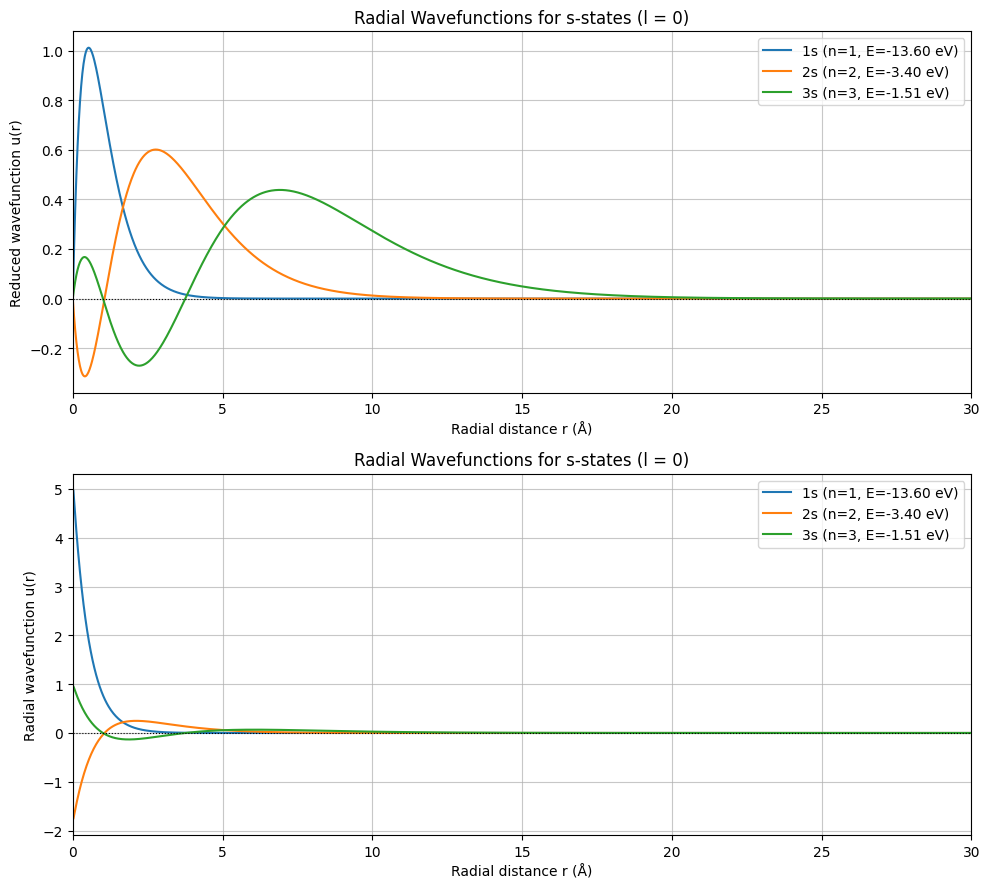

In [38]:
ri = 1e-4 
rf = 40.0
interior_points = 2000
l = 0
state_names = ["1s","2s","3s"]
same_l_different_n(ri,rf,interior_points,l,state_names)


**Plotting one value of n for multiple l**

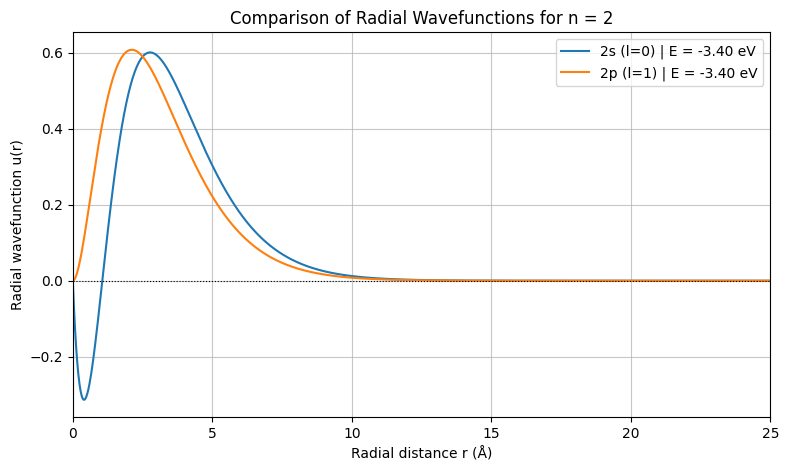

In [18]:
ri = 1e-4 
rf = 40.0  
interior_points = 2000

n = 2
plt.figure(figsize=(9,5))

l_labels = {0: "2s (l=0)", 1: "2p (l=1)"}

for l in range(n):
    state_index = n - l - 1
    grid,u_norm,energy,r_final = solve_potential(ri, rf, interior_points, l, state_index)
    plt.plot(grid, u_norm, label=f"{l_labels[l]} | E = {energy:.2f} eV")

plt.axhline(0, color='black', linewidth=0.8, linestyle=':')
plt.grid(True, alpha=0.7)
plt.xlim(0, 25)
plt.xlabel("Radial distance r (Å)")
plt.ylabel("Radial wavefunction u(r)")
plt.title(f"Comparison of Radial Wavefunctions for n = {n}")
plt.legend()
plt.show()